# Comparing optimal paths between mazes (barrier change sessions)

For a barrier change session, we're often interested in the rat's choice between the previously-optimal path on the old maze and the now-optimal path on the new maze.

We have a couple of functions to identify hexes on the divergence/convergence hexes between old and optimal paths, as well as the hexes before path divergence and hexes unique to the old/new paths.

Maze 1: frozenset({np.int64(37), np.int64(7), np.int64(42), np.int64(44), np.int64(14), np.int64(20), np.int64(25), np.int64(28), np.int64(31)})
Maze 2: frozenset({37, 7, 42, 44, 14, 17, 20, 25, 28})

Port 1 to Port 2:
Old paths: [[1, 4, 6, 8, 10, 13, 17, 21, 26, 22, 27, 32, 38, 49, 2]]
New paths: [[1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 35, 30, 36, 31, 26, 22, 27, 32, 38, 49, 2]]
Paths diverge at hex 13, converge at hex 26
Unique hexes on old path: {17, 21}
Unique hexes on new path: {35, 36, 12, 15, 16, 19, 24, 29, 30, 31}

Port 1 to Port 3:
Old paths: [[1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 39, 43, 48, 3]]
New paths: [[1, 4, 6, 8, 10, 13, 16, 12, 15, 19, 24, 29, 34, 39, 43, 48, 3]]
Paths diverge at hex None, converge at hex None
Unique hexes on old path: set()
Unique hexes on new path: set()

Port 2 to Port 3:
Old paths: [[2, 49, 38, 32, 27, 22, 26, 21, 17, 13, 16, 12, 15, 19, 24, 29, 34, 39, 43, 48, 3]]
New paths: [[2, 49, 38, 32, 27, 22, 26, 31, 36, 30, 35, 29, 34, 3

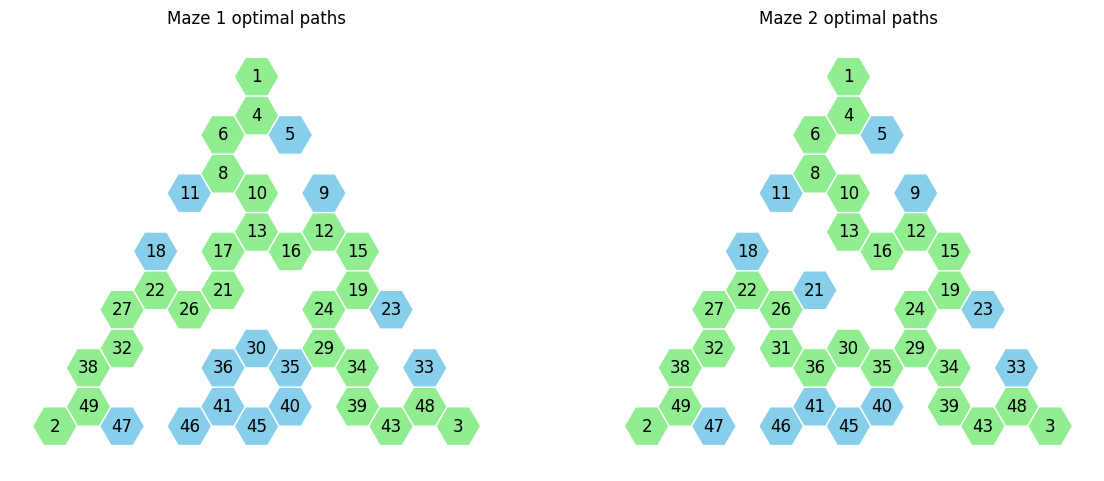

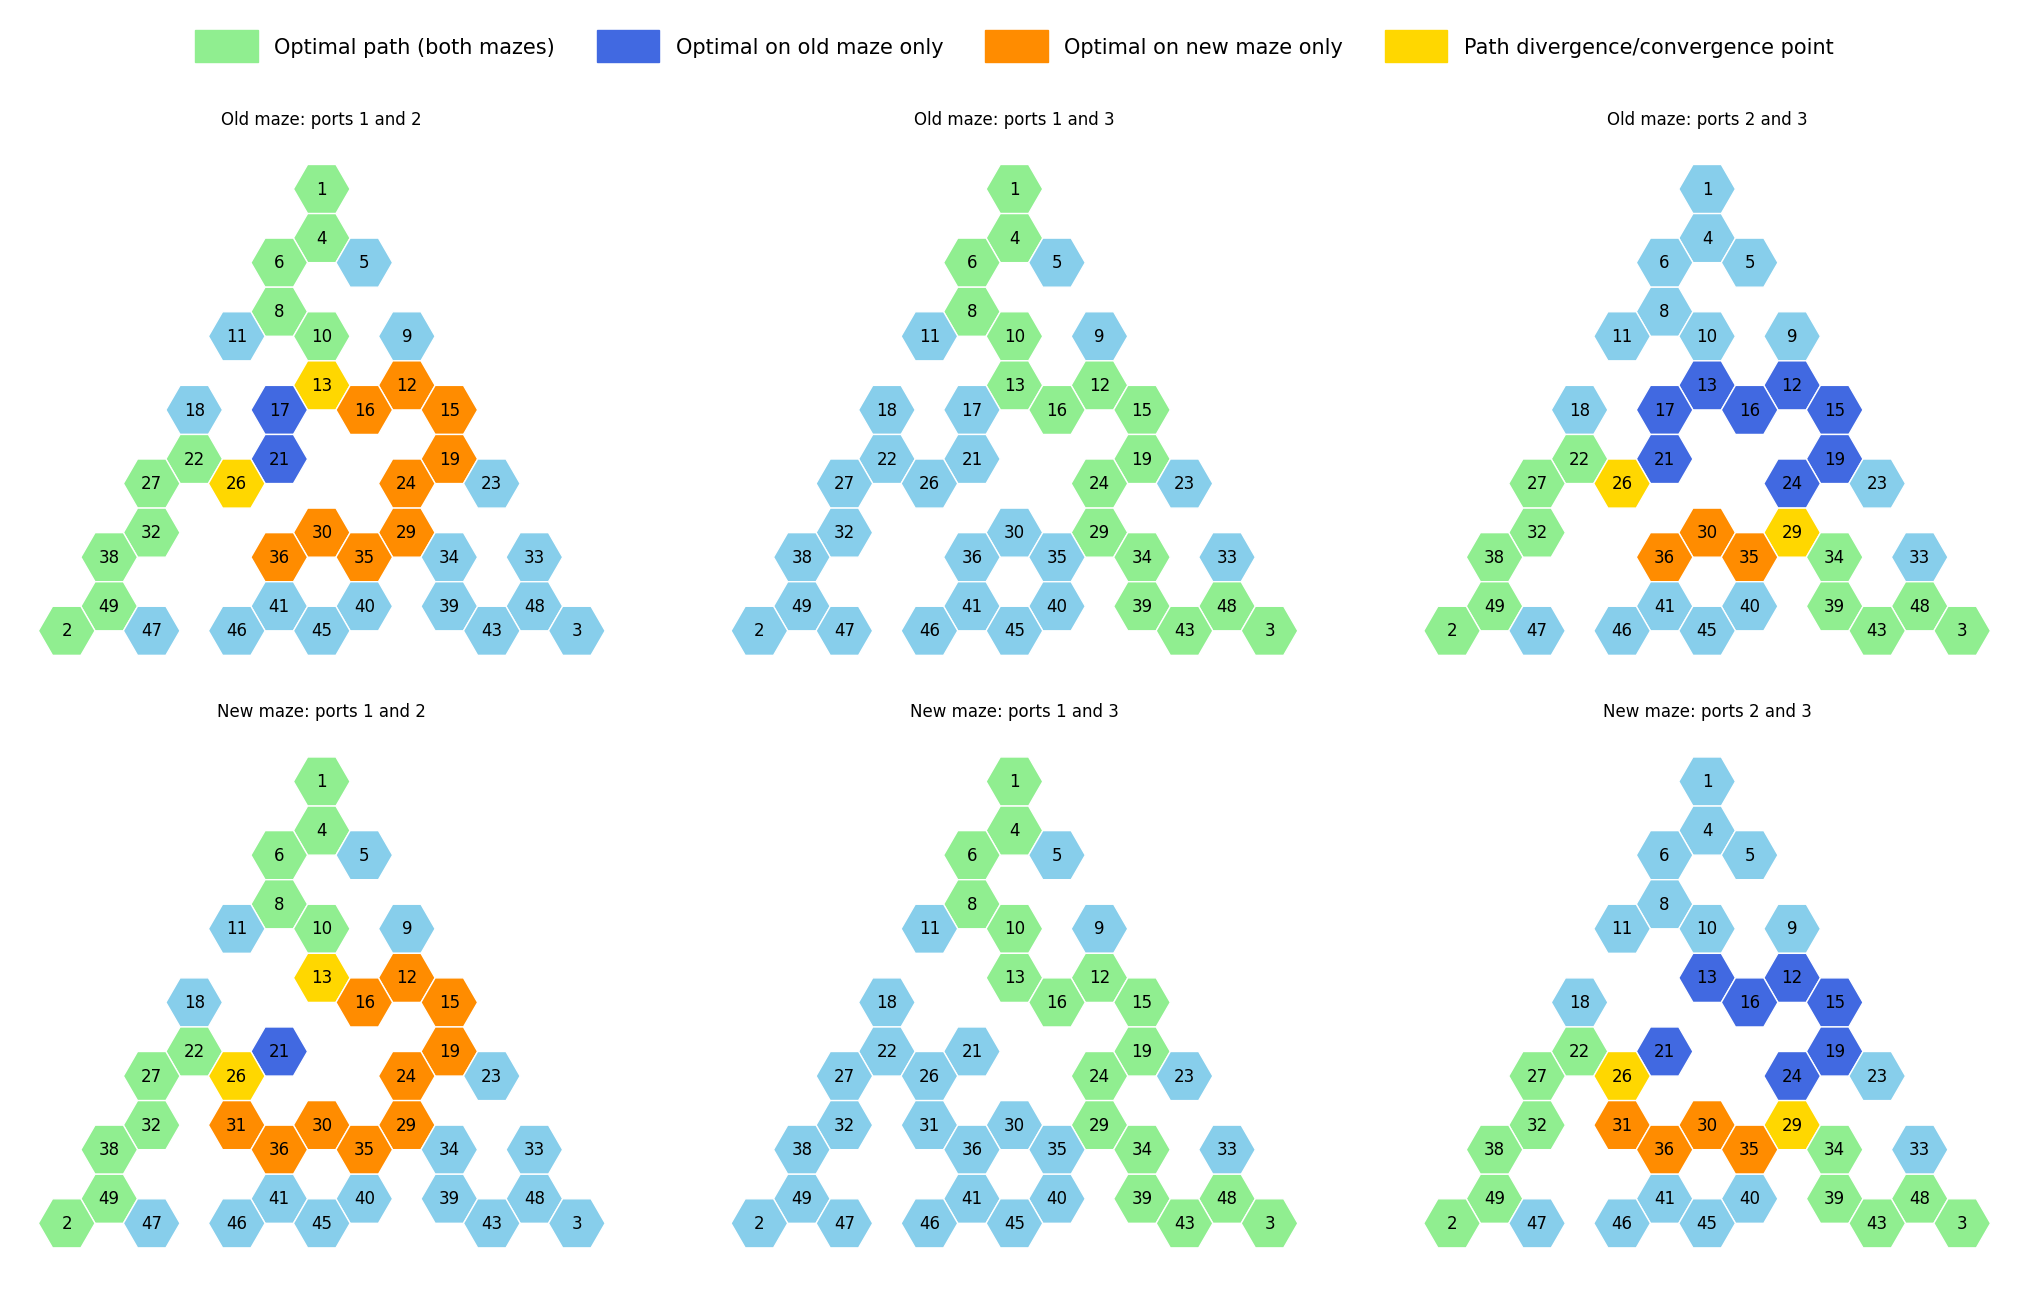

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import sys
sys.path.append("..") # Use sys to add the parent directory (where src/hexmaze lives) to the path

from src.hexmaze import (
    plot_hex_maze,
    get_all_path_pairs,
    get_old_and_new_paths,
    get_path_divergence_point,
    get_path_convergence_point,
    get_hexes_after_divergence,
    get_optimal_paths,
)

# Load the barrier sequence database and grab 2 mazes that differ by one barrier
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[3]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

# Plot the 2 mazes with optimal paths shown
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].set_title("Maze 1 optimal paths")
print(f"Maze 1: {maze_1}")
plot_hex_maze(maze_1, ax=axes[0], show_barriers=False, show_optimal_paths=True)
axes[1].set_title("Maze 2 optimal paths")
plot_hex_maze(maze_2, ax=axes[1], show_barriers=False, show_optimal_paths=True)
print(f"Maze 2: {maze_2}")

# Compare old vs new optimal paths for each port pair
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Hex where optimal paths between these ports diverge
    divergence_point = get_path_divergence_point(maze_1, maze_2, start, end)
    # Hex where optimal paths between these ports converge (aka divergence point if start/end port order was switched)
    convergence_point = get_path_convergence_point(maze_1, maze_2, start, end)
    # Get the old and new optimal paths between ports
    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)
    # Get hexes unique to the old and new path between ports (between divergence/convergence)
    hexes_on_old_path, hexes_on_new_path = get_hexes_after_divergence(maze_1, maze_2, start, end)
    print(f"\nPort {start} to Port {end}:")
    print(f"Old paths: {old_paths}")
    print(f"New paths: {new_paths}")
    print(f"Paths diverge at hex {divergence_point}, converge at hex {convergence_point}")
    print(f"Unique hexes on old path: {hexes_on_old_path}")
    print(f"Unique hexes on new path: {hexes_on_new_path}")
    
    # Highlight optimal paths between ports in light green
    # (because differing hexes on optimal paths will be overridden by subsequent highlights,
    # we can use get_optimal_paths for maze_1 and use it for both maze 1 and 2)
    optimal_paths = get_optimal_paths(maze_1, start, end)
    optimal_path_hexes = {hex for path in optimal_paths for hex in path}

    # Highlight old path hexes in blue, new path hexes in orange, 
    # and path divergence/convergence points in gold
    path_choice_points = set()
    if divergence_point is not None:
        path_choice_points.add(divergence_point)
    if convergence_point is not None:
        path_choice_points.add(convergence_point)

    highlight = [optimal_path_hexes, hexes_on_old_path, hexes_on_new_path, path_choice_points]
    colors = ["lightgreen", "royalblue", "darkorange", "gold"]

    # Plot the path difference on the old maze
    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight, highlight_colors=colors, show_barriers=False)
    axes[0, i].set_title(f"Old maze: ports {start} and {end}")

    # Plot the path difference on the new maze
    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight, highlight_colors=colors, show_barriers=False)
    axes[1, i].set_title(f"New maze: ports {start} and {end}")

# Define legend handles
legend_handles = [
    mpatches.Patch(color="lightgreen", label="Optimal path (both mazes)"),
    mpatches.Patch(color="royalblue", label="Optimal on old maze only"),
    mpatches.Patch(color="darkorange", label="Optimal on new maze only"),
    mpatches.Patch(color="gold", label="Path divergence/convergence point"),
]

# Add a single shared legend outside the plots
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False,)

plt.tight_layout()
plt.show()


## Get hexes before path divergence

When the rat is deciding between paths, we may want to see what he is thinking about while he is in the hexes before path divergence. We can use `get_hexes_before_divergence` to identify these hexes. Additional args `dead_end_ok` and `non_optimal_ok` (both True by default) can restrict these hexes to optimal paths, vs all possible hexes before the choice.

Note that this uses the most similar pair of old/new paths between ports.

Port 1 to Port 2: 8 hexes before divergence = {1, 4, 5, 6, 8, 10, 11, 13}
Port 1 to Port 3: 0 hexes before divergence = set()
Port 2 to Port 3: 9 hexes before divergence = {32, 2, 38, 47, 49, 18, 22, 26, 27}


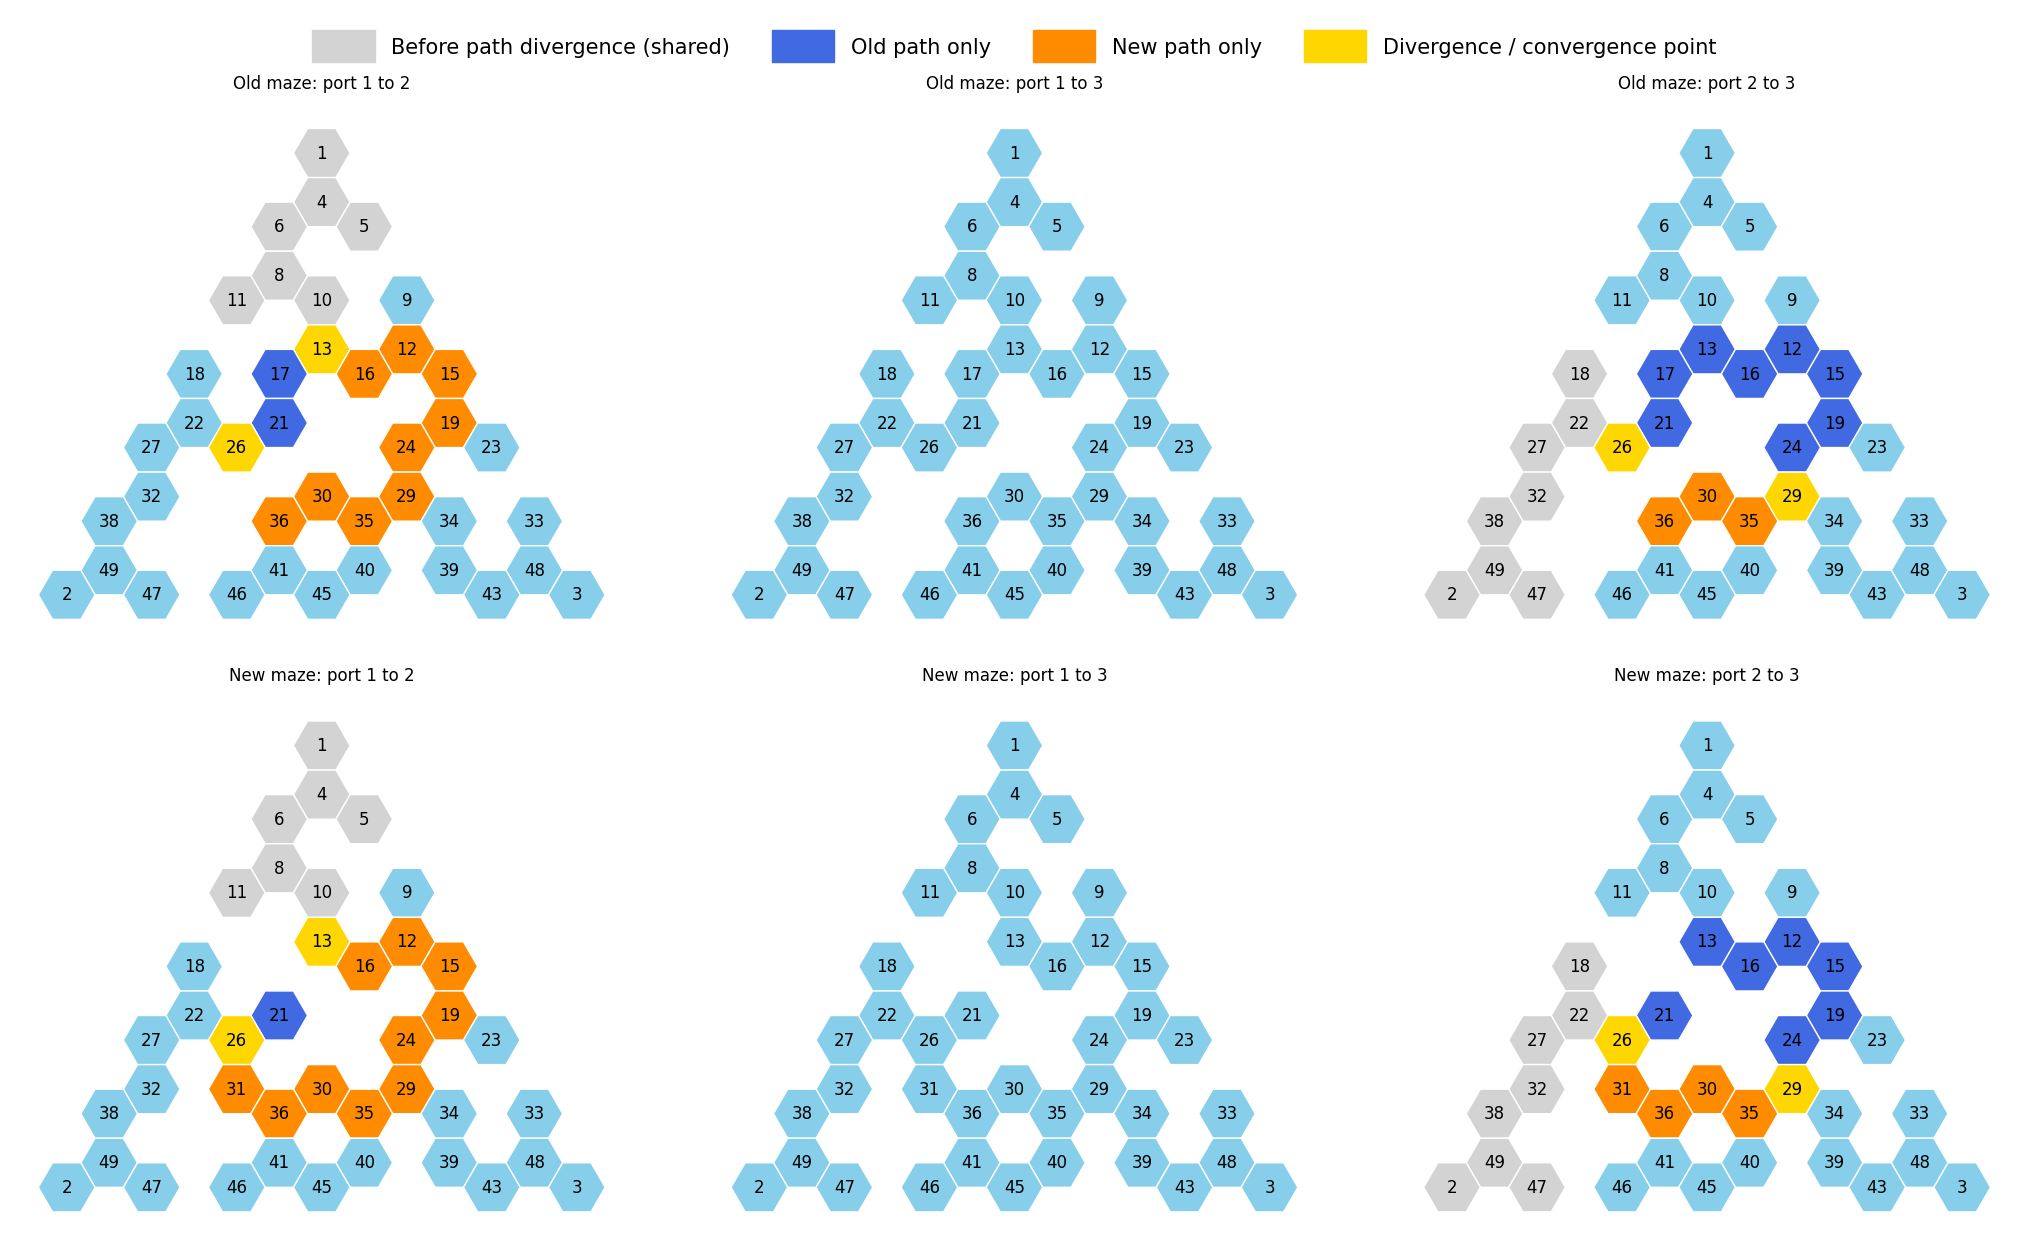

Port 2 to Port 1: 9 hexes before divergence = {32, 2, 38, 47, 49, 18, 22, 26, 27}
Port 3 to Port 1: 0 hexes before divergence = set()
Port 3 to Port 2: 7 hexes before divergence = {48, 33, 34, 3, 39, 43, 29}


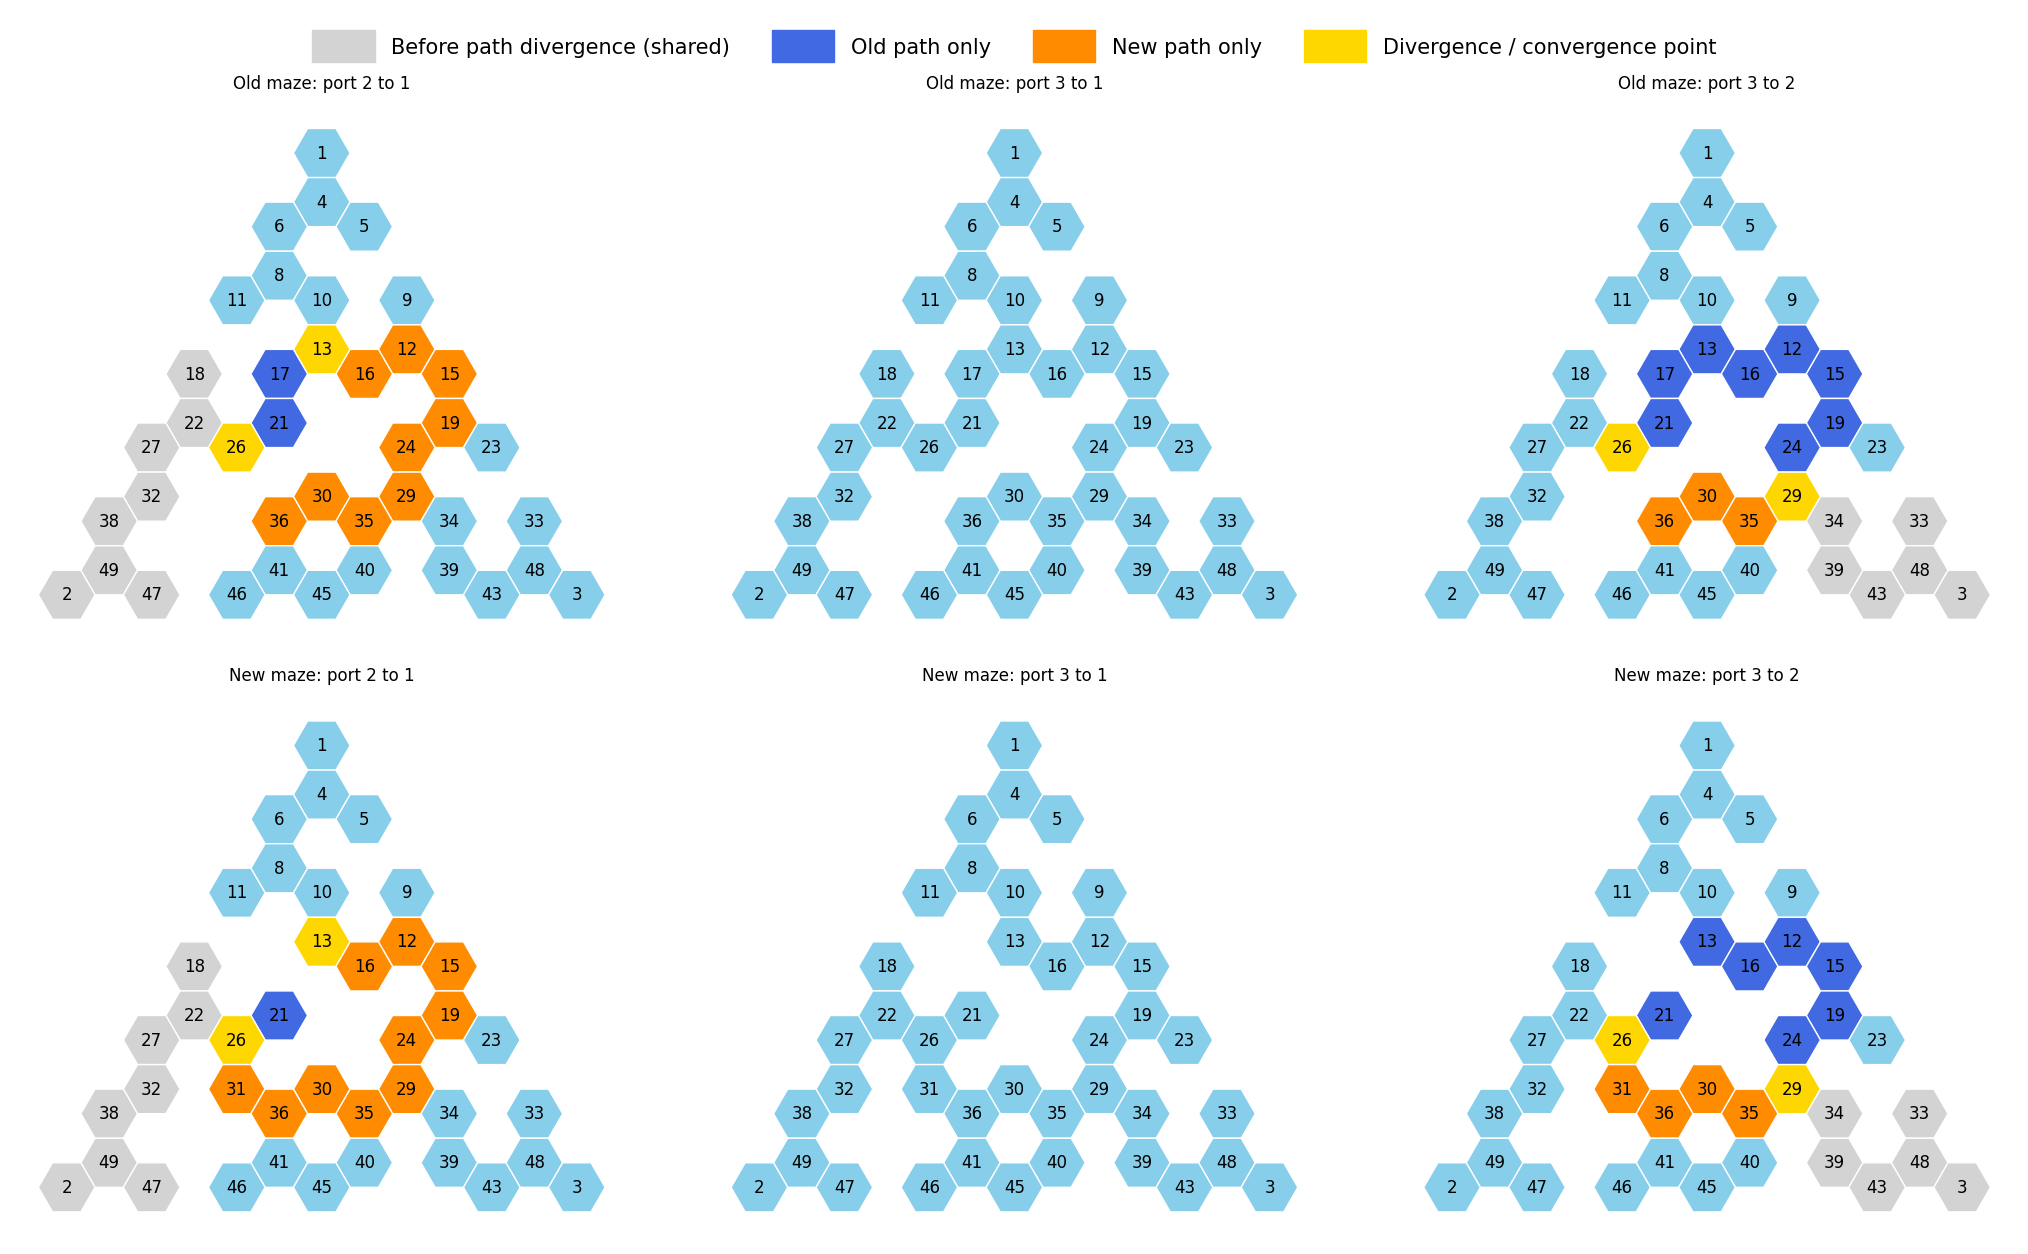

In [9]:
from src.hexmaze import get_hexes_before_divergence

fig, axes = plt.subplots(2, 3, figsize=(21, 12))

# Loop through port pairs
for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get hexes before divergence (including non-optimal and dead ends)
    before_div = get_hexes_before_divergence(maze_1, maze_2, start, end)
    # Get hexes unique to old/new paths
    hexes_on_old_path, hexes_on_new_path = get_hexes_after_divergence(maze_1, maze_2, start, end)

    # Get divergence/convergence point of most similar paths
    divergence_point = get_path_divergence_point(maze_1, maze_2, start, end)
    convergence_point = get_path_convergence_point(maze_1, maze_2, start, end)
    
    # Print set of hexes before divergence
    print(f"Port {start} to Port {end}: {len(before_div)} hexes before divergence = {before_div}")

    key_points = set()
    if divergence_point is not None:
        key_points.add(divergence_point)
    if convergence_point is not None:
        key_points.add(convergence_point)

    # Plot hexes before divergence in light grey, old path in blue,
    # new path in orange, and divergence/convergence hexes in gold
    highlight = [before_div - key_points, hexes_on_old_path, hexes_on_new_path, key_points]
    colors = ["lightgray", "royalblue", "darkorange", "gold"]

    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[0, i].set_title(f"Old maze: port {start} to {end}")

    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[1, i].set_title(f"New maze: port {start} to {end}")

legend_handles = [
    mpatches.Patch(color="lightgray", label="Before path divergence (shared)"),
    mpatches.Patch(color="royalblue", label="Old path only"),
    mpatches.Patch(color="darkorange", label="New path only"),
    mpatches.Patch(color="gold", label="Divergence / convergence point"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


## Same port pairs but in the other direction
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

# Loop through port pairs (but now switch start and end port)
for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get hexes before divergence (including non-optimal and dead ends)
    before_div = get_hexes_before_divergence(maze_1, maze_2, end, start)
    # Get hexes unique to old/new paths
    hexes_on_old_path, hexes_on_new_path = get_hexes_after_divergence(maze_1, maze_2, end, start)

    # Get divergence/convergence point of most similar paths
    divergence_point = get_path_divergence_point(maze_1, maze_2, end, start)
    convergence_point = get_path_convergence_point(maze_1, maze_2, end, start)
    print(f"Port {end} to Port {start}: {len(before_div)} hexes before divergence = {before_div}")

    key_points = set()
    if divergence_point is not None:
        key_points.add(divergence_point)
    if convergence_point is not None:
        key_points.add(convergence_point)
        
    # Plot hexes before divergence in light grey, old path in blue,
    # new path in orange, and divergence/convergence hexes in gold
    highlight = [before_div - key_points, hexes_on_old_path, hexes_on_new_path, key_points]
    colors = ["lightgray", "royalblue", "darkorange", "gold"]

    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[0, i].set_title(f"Old maze: port {end} to {start}")

    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=highlight,
                  highlight_colors=colors, show_hex_labels=True, show_barriers=False)
    axes[1, i].set_title(f"New maze: port {end} to {start}")

legend_handles = [
    mpatches.Patch(color="lightgray", label="Before path divergence (shared)"),
    mpatches.Patch(color="royalblue", label="Old path only"),
    mpatches.Patch(color="darkorange", label="New path only"),
    mpatches.Patch(color="gold", label="Divergence / convergence point"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.05), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


## `get_old_and_new_paths` — all optimal paths between two ports on each maze
Returns all optimal paths (there may be more than one) for each maze between a given port pair.

Note that this is the same as just calling `get_optimal_paths` for each maze.


Port 1 to Port 2:
  Old maze has 1 optimal path(s): [[1, 4, 5, 7, 9, 12, 16, 20, 24, 29, 35, 40, 45, 41, 36, 31, 37, 42, 47, 49, 2]]
  New maze has 2 optimal path(s): [[1, 4, 5, 7, 10, 13, 17, 14, 18, 22, 26, 31, 37, 42, 47, 49, 2], [1, 4, 6, 8, 10, 13, 17, 14, 18, 22, 26, 31, 37, 42, 47, 49, 2]]
Port 1 to Port 3:
  Old maze has 1 optimal path(s): [[1, 4, 5, 7, 9, 12, 16, 20, 24, 19, 23, 28, 33, 48, 3]]
  New maze has 2 optimal path(s): [[1, 4, 5, 7, 10, 13, 17, 14, 18, 22, 26, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3], [1, 4, 6, 8, 10, 13, 17, 14, 18, 22, 26, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3]]
Port 2 to Port 3:
  Old maze has 1 optimal path(s): [[2, 49, 47, 42, 37, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3]]
  New maze has 1 optimal path(s): [[2, 49, 47, 42, 37, 31, 36, 41, 45, 40, 35, 29, 24, 19, 23, 28, 33, 48, 3]]


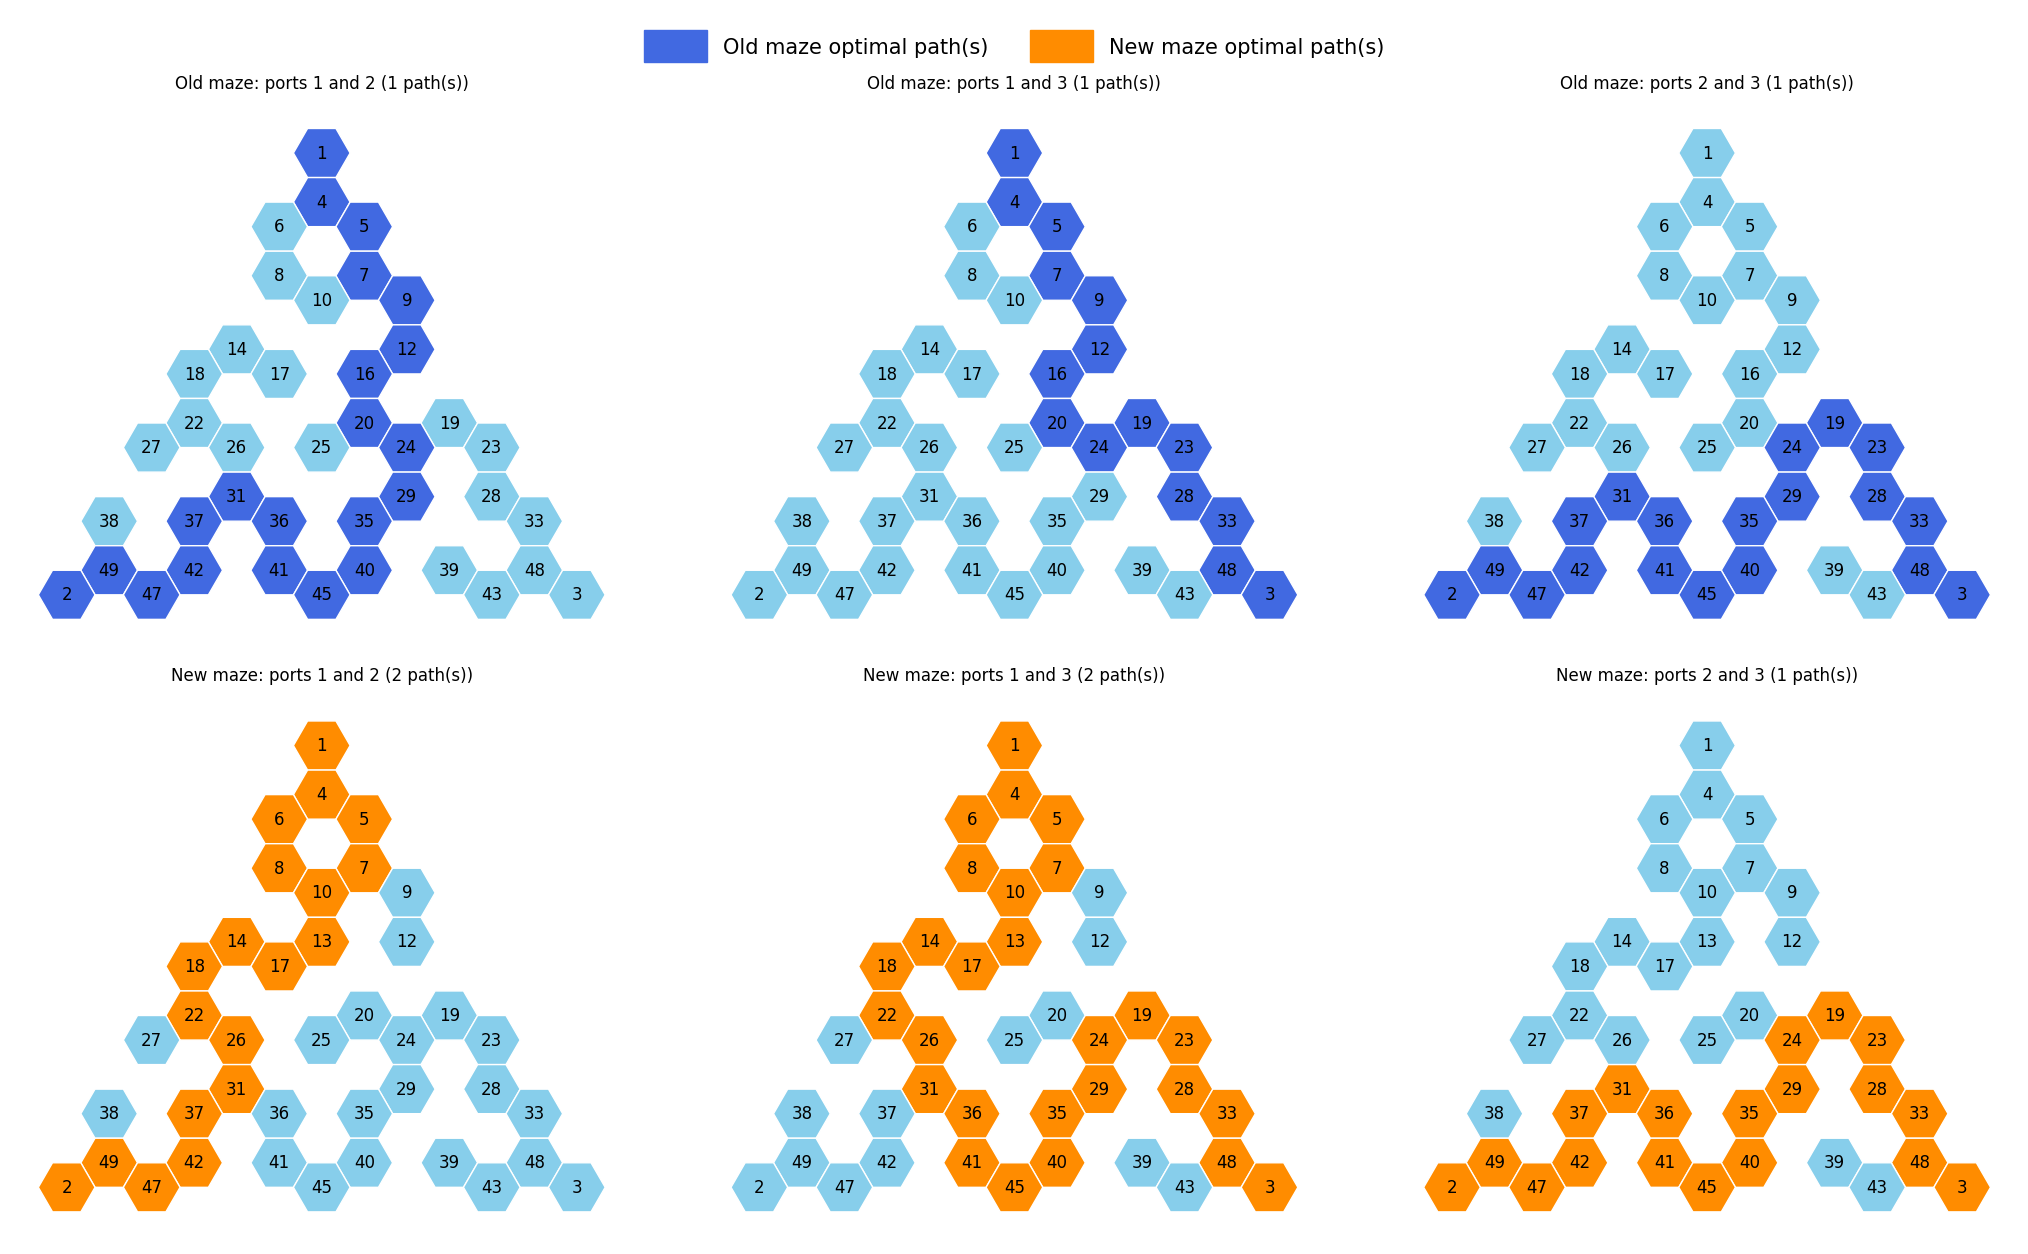

In [10]:
# Grab 2 mazes where one of the mazes has multiple optimal paths
barrier_sequence_database = pd.read_pickle('../Barrier_Sequence_Databases/barrier_sequence_database.pkl')
sequence = barrier_sequence_database.iloc[2]['barrier_sequence']
maze_1, maze_2 = sequence[0], sequence[1]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))

for i, (start, end) in enumerate([(1, 2), (1, 3), (2, 3)]):
    # Get all optimal paths between these ports on each maze
    old_paths, new_paths = get_old_and_new_paths(maze_1, maze_2, start, end)
    print(f"Port {start} to Port {end}:")
    print(f"  Old maze has {len(old_paths)} optimal path(s): {old_paths}")
    print(f"  New maze has {len(new_paths)} optimal path(s): {new_paths}")

    # Combine all old/new paths into highlight sets
    old_path_hexes = {h for path in old_paths for h in path}
    new_path_hexes = {h for path in new_paths for h in path}

    # Plot all old paths on maze 1
    plot_hex_maze(maze_1, ax=axes[0, i], highlight_hexes=[old_path_hexes],
                  highlight_colors=["royalblue"], show_hex_labels=True, show_barriers=False)
    axes[0, i].set_title(f"Old maze: ports {start} and {end} ({len(old_paths)} path(s))")

    # Plot all new paths on maze 2
    plot_hex_maze(maze_2, ax=axes[1, i], highlight_hexes=[new_path_hexes],
                  highlight_colors=["darkorange"], show_hex_labels=True, show_barriers=False)
    axes[1, i].set_title(f"New maze: ports {start} and {end} ({len(new_paths)} path(s))")

legend_handles = [
    mpatches.Patch(color="royalblue", label="Old maze optimal path(s)"),
    mpatches.Patch(color="darkorange", label="New maze optimal path(s)"),
]
fig.legend(handles=legend_handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), fontsize=15,
    handlelength=3, handleheight=2, borderpad=1, frameon=False)
plt.tight_layout()
plt.show()


## Exploring all path pairs
When a maze has multiple optimal paths, the "most similar" pair is used by default. But different pairings can produce different divergence/convergence points. `get_all_path_pairs` returns all (old, new) combinations sorted by similarity.

Port 1 to Port 2: 2 path pair(s)


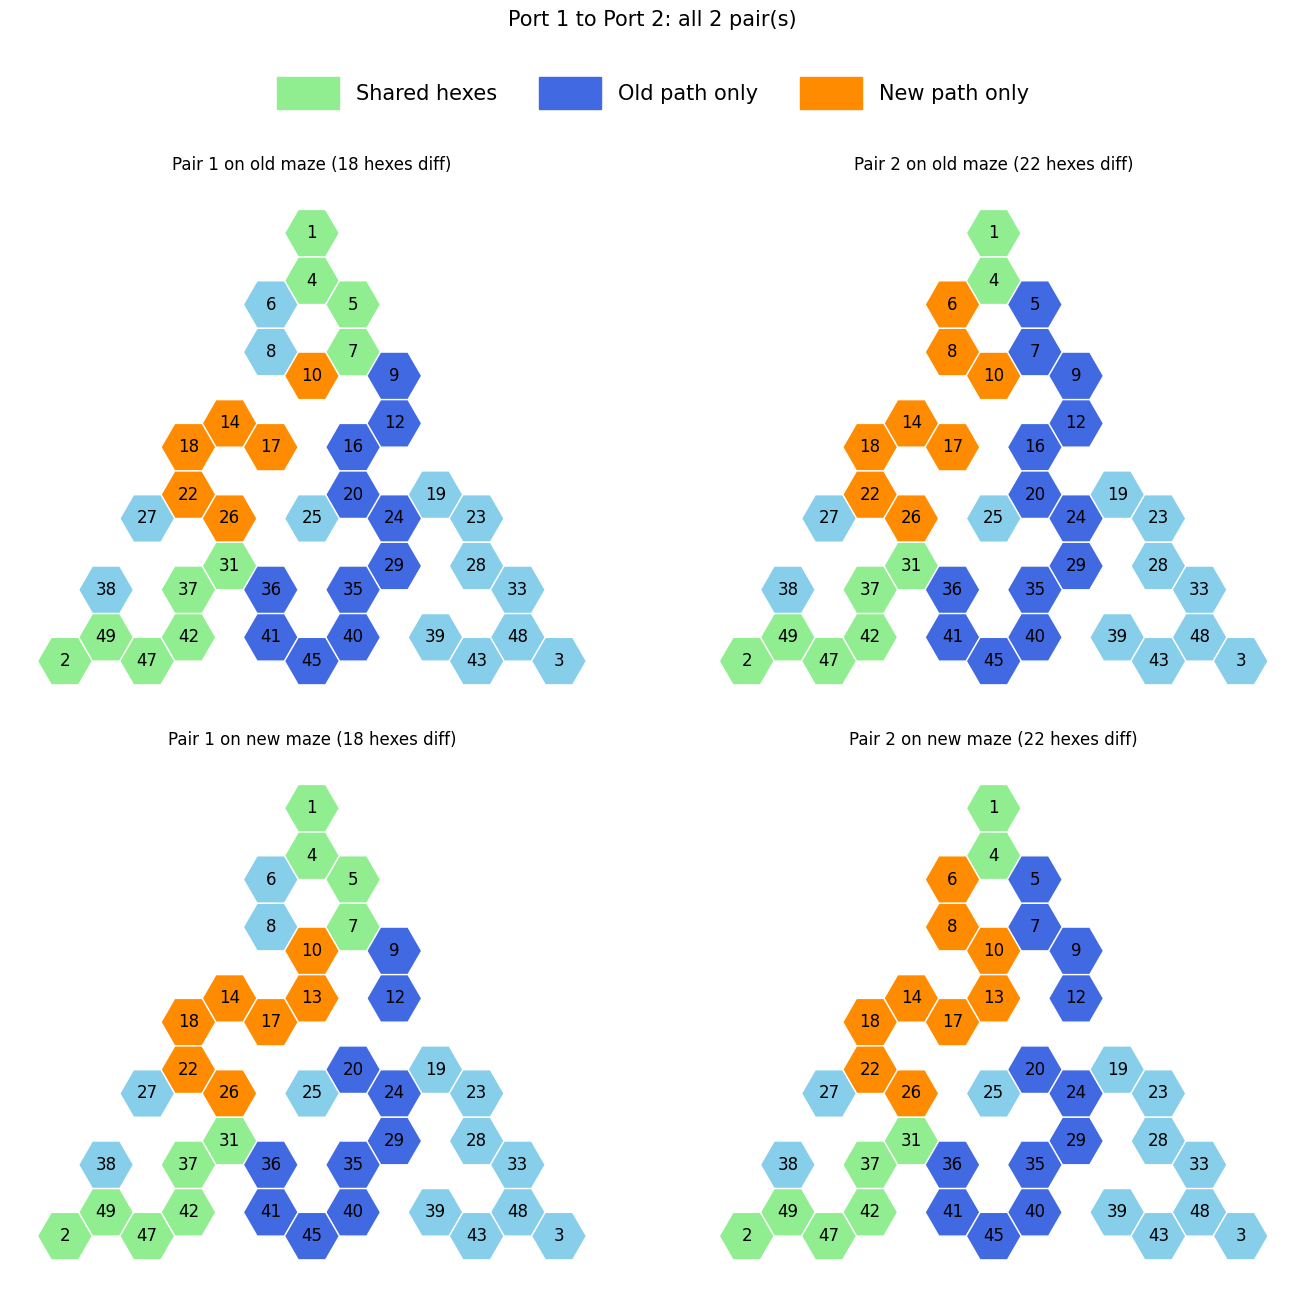

Port 1 to Port 3: 2 path pair(s)


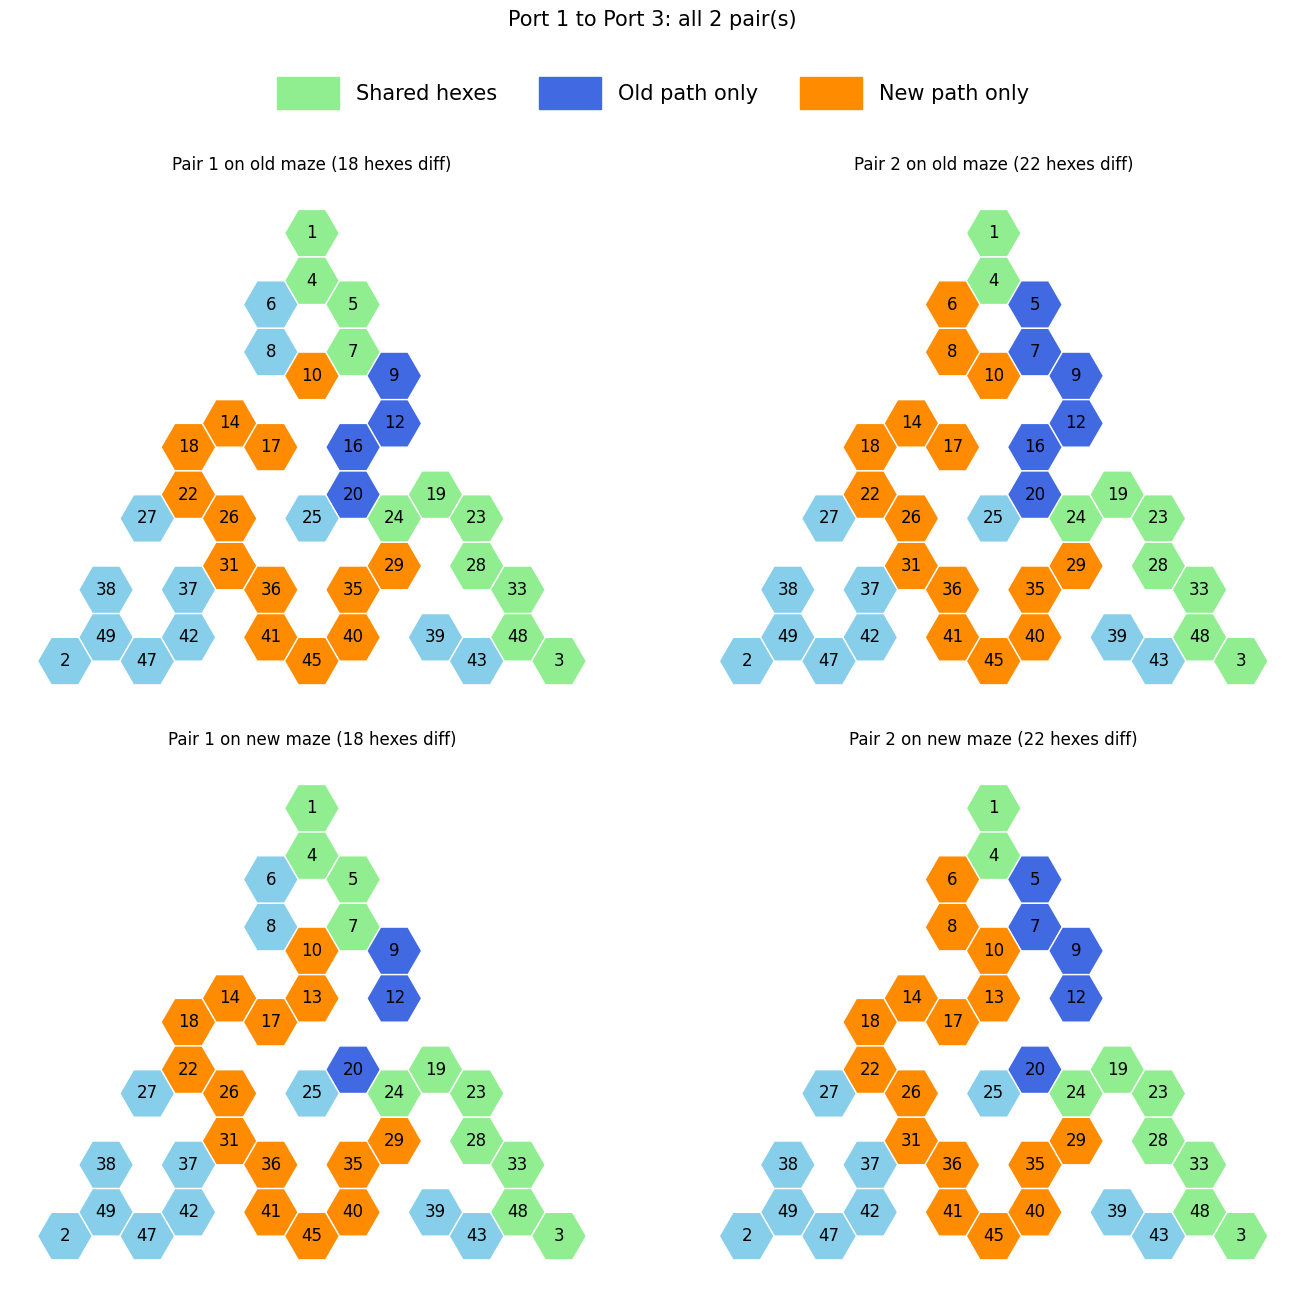

Port 2 to Port 3: 1 path pair(s)


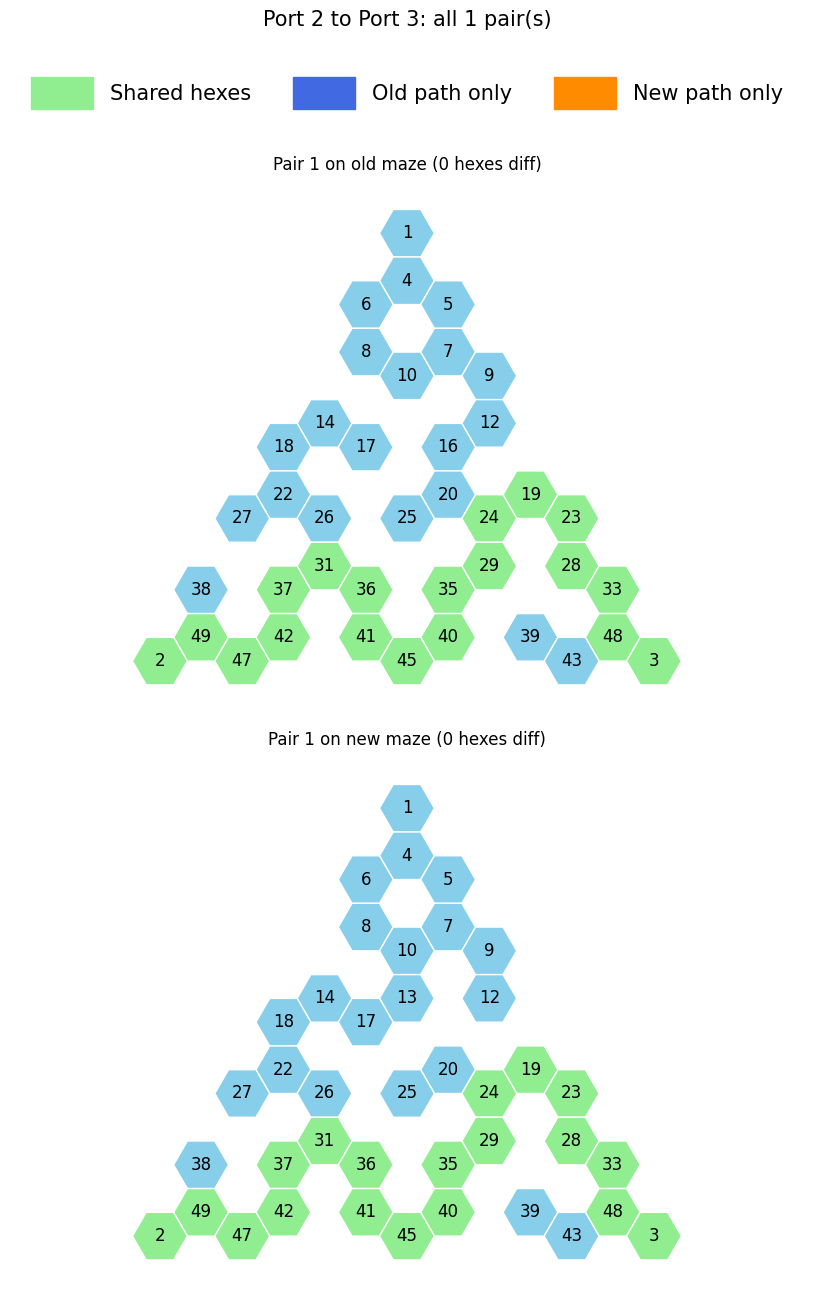

In [13]:
from src.hexmaze import get_all_path_pairs

for start, end in [(1, 2), (1, 3), (2, 3)]:
    all_pairs = get_all_path_pairs(maze_1, maze_2, start, end)
    if not all_pairs:
        old_paths, _ = get_old_and_new_paths(maze_1, maze_2, start, end)
        all_pairs = [(old_paths[0], old_paths[0])]

    n_pairs = len(all_pairs)
    print(f"Port {start} to Port {end}: {n_pairs} path pair(s)")

    fig, axes = plt.subplots(2, n_pairs, figsize=(7 * n_pairs, 12))
    if n_pairs == 1:
        axes = axes.reshape(2, 1)

    for j, (old_path, new_path) in enumerate(all_pairs):
        diff = len(set(old_path).symmetric_difference(set(new_path)))
        shared = set(old_path) & set(new_path)
        old_only = set(old_path) - shared
        new_only = set(new_path) - shared

        highlight = [shared, old_only, new_only]
        colors = ["lightgreen", "royalblue", "darkorange"]

        plot_hex_maze(maze_1, ax=axes[0, j], highlight_hexes=highlight,
                      highlight_colors=colors, show_hex_labels=True, show_barriers=False)
        axes[0, j].set_title(f"Pair {j+1} on old maze ({diff} hexes diff)")

        plot_hex_maze(maze_2, ax=axes[1, j], highlight_hexes=highlight,
                      highlight_colors=colors, show_hex_labels=True, show_barriers=False)
        axes[1, j].set_title(f"Pair {j+1} on new maze ({diff} hexes diff)")

    legend_handles = [
        mpatches.Patch(color="lightgreen", label="Shared hexes"),
        mpatches.Patch(color="royalblue", label="Old path only"),
        mpatches.Patch(color="darkorange", label="New path only"),
    ]
    fig.legend(handles=legend_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=15,
        handlelength=3, handleheight=2, borderpad=1, frameon=False)
    fig.suptitle(f"Port {start} to Port {end}: all {n_pairs} pair(s)", fontsize=15, y=1.08)
    plt.tight_layout()
    plt.show()
